In [ ]:
import torch
import torch.nn as nn
from transformers import AutoTokenizer, AutoModelForSequenceClassification, Trainer, TrainingArguments, EarlyStoppingCallback, RobertaModel, RobertaTokenizer
from torch.utils.data import DataLoader, Dataset
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score, accuracy_score, precision_score, recall_score, confusion_matrix, classification_report, ConfusionMatrixDisplay
from sklearn.cluster import DBSCAN
from sklearn.utils.class_weight import compute_class_weight

In [ ]:
from google.colab import drive
drive.mount('/content/drive/',force_remount=False)

Drive already mounted at /content/drive/; to attempt to forcibly remount, call drive.mount("/content/drive/", force_remount=True).


In [ ]:
kaggle_df = pd.read_csv('/content/drive/MyDrive/thesis/kaggle/final/kaggle_df.csv')

kaggle_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 30 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Username                     1000 non-null   object 
 1   Display_Name                 1000 non-null   object 
 2   Gender                       1000 non-null   object 
 3   notebook_url                 1000 non-null   object 
 4   code_location                1000 non-null   object 
 5   labels                       1000 non-null   object 
 6   top_labels                   1000 non-null   object 
 7   code_sections                1000 non-null   object 
 8   markdown_sections            1000 non-null   object 
 9   all_sections                 1000 non-null   object 
 10  only_code_in_code_sections   1000 non-null   object 
 11  number_of_lines              1000 non-null   float64
 12  names_set                    1000 non-null   object 
 13  num_of_sections    

In [ ]:
kaggle_df.drop_duplicates(subset=['only_code_in_code_sections'], inplace=True, keep=False)

kaggle_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 998 entries, 0 to 999
Data columns (total 30 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Username                     998 non-null    object 
 1   Display_Name                 998 non-null    object 
 2   Gender                       998 non-null    object 
 3   notebook_url                 998 non-null    object 
 4   code_location                998 non-null    object 
 5   labels                       998 non-null    object 
 6   top_labels                   998 non-null    object 
 7   code_sections                998 non-null    object 
 8   markdown_sections            998 non-null    object 
 9   all_sections                 998 non-null    object 
 10  only_code_in_code_sections   998 non-null    object 
 11  number_of_lines              998 non-null    float64
 12  names_set                    998 non-null    object 
 13  num_of_sections          

In [ ]:
kaggle_df.Gender.value_counts()

,count
Gender,
male,563
female,435


In [ ]:
kaggle_df.describe()

,number_of_lines,num_of_sections,token_count,variables_count,function_count,loop_count,condition_count,single_line_comment_density,function_density,loop_density,condition_density,comment_tokens_density,avg_var_name_length,comment_to_code_ratio,avg_func_length,code_to_markdown_ratio,avg_markdown_lines_length,markdown_sentiment
count,998.000000,998.000000,998.000000,998.000000,998.000000,998.000000,998.000000,998.000000,998.000000,998.000000,998.000000,998.000000,998.000000,998.000000,998.000000,998.000000,998.000000,998.000000
mean,217.010020,23.555110,272.813627,121.988978,4.982966,6.723447,4.387776,0.107640,0.013940,0.023342,0.012742,0.174291,7.414287,0.443498,11.336184,498.285751,2.787365,0.120990
std,237.479539,25.785328,297.044896,89.032923,8.867616,9.745903,9.687025,0.102016,0.018754,0.027894,0.023146,0.175557,1.109271,0.775672,14.410065,1648.674900,3.341100,0.187677
min,1.000000,1.000000,8.000000,6.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.833333,0.000045,0.000000,0.133948,0.000000,-0.919300
25%,76.000000,11.000000,147.000000,60.000000,0.000000,1.000000,0.000000,0.030543,0.000000,0.007467,0.000000,0.028095,6.663760,0.024171,0.000000,2.136139,1.000000,0.000000
50%,149.500000,19.000000,229.000000,100.000000,1.000000,4.000000,1.000000,0.082055,0.006981,0.016949,0.005626,0.126262,7.423927,0.151531,7.741667,6.842458,1.857143,0.062896
75%,267.000000,30.000000,335.000000,165.750000,6.000000,8.000000,5.000000,0.150101,0.021810,0.031408,0.019001,0.265457,8.062869,0.501260,17.262874,42.750830,3.829545,0.209336
max,2220.000000,629.000000,6143.000000,754.000000,88.000000,120.000000,120.000000,0.825000,0.147404,0.481928,0.481928,0.811765,17.230216,7.045455,99.500000,22501.500000,47.000000,0.967450


In [ ]:
def concatenate_code_sections(row, unique_char):
    code_list = eval(row)
    concatenated_code = unique_char.join(code_list)
    return concatenated_code

kaggle_df['parsed_code'] = kaggle_df['only_code_in_code_sections'].apply(concatenate_code_sections, unique_char='\n')

In [ ]:
X=kaggle_df.drop('Gender',axis=1)
Y=kaggle_df.Gender

In [ ]:
X_train_text, X_test_text, Y_train, y_test = train_test_split(X.parsed_code, Y, test_size=0.2, random_state=0,stratify=Y)

In [ ]:
X_train_text, X_valid_text, y_train, y_valid = train_test_split(X_train_text, Y_train, test_size=0.125, random_state=0,stratify=Y_train)

In [ ]:
enc = LabelEncoder()
y_train = enc.fit_transform(y_train)
y_valid = enc.transform(y_valid)
y_test = enc.transform(y_test)

In [ ]:
num_labels = len(enc.classes_)
num_labels

2

## CodeBert

In [ ]:
# Set device to GPU if available, otherwise use CPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

# Define the tokenizer and the model
model_name = "microsoft/codebert-base"
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=num_labels)

Using device: cuda


/usr/local/lib/python3.10/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/498 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/150 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/499M [00:00<?, ?B/s]

Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at microsoft/codebert-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [ ]:
# define the dataset
class CodeDataset(Dataset):
    def __init__(self, code_series, country_series):
        self.samples = [(code, country_series[index]) for index, code in code_series.items()]

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, index):
        code, label = self.samples[index]
        inputs = tokenizer.encode_plus(code, padding='max_length', max_length=512, truncation=True)
        input_ids = inputs['input_ids']
        attention_mask = inputs['attention_mask']
        return {
            'input_ids': torch.tensor(input_ids, dtype=torch.long),
            'attention_mask': torch.tensor(attention_mask, dtype=torch.long),
            'labels': torch.tensor(label, dtype=torch.long)
        }

In [ ]:
# Define the training dataset and dataloader
train_dataset = CodeDataset(X_train_text.reset_index(drop=True), y_train)
train_dataloader = DataLoader(train_dataset, batch_size=32, shuffle=True)

valid_dataset = CodeDataset(X_valid_text.reset_index(drop=True), y_valid)
valid_dataloader = DataLoader(valid_dataset, batch_size=32, shuffle=True)

# Define the testing dataset and dataloader
test_dataset = CodeDataset(X_test_text.reset_index(drop=True), y_test)
test_dataloader = DataLoader(test_dataset, batch_size=32, shuffle=False)

In [ ]:
# Step 1: Calculate class weights based on your dataset
class_weights = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
class_weights = torch.tensor(class_weights, dtype=torch.float)

# Step 2: Define a custom Trainer to incorporate class weights
class WeightedTrainer(Trainer):
    def compute_loss(self, model, inputs, return_outputs=False):
        labels = inputs.pop("labels")
        outputs = model(**inputs)
        logits = outputs.logits

        # Define the weighted loss
        loss_fn = torch.nn.CrossEntropyLoss(weight=class_weights.to(logits.device))
        loss = loss_fn(logits, labels)

        return (loss, outputs) if return_outputs else loss

In [ ]:
# Define the training arguments
training_args = TrainingArguments(
    output_dir='./results',
    report_to=['none'],
    num_train_epochs=10,
    per_device_train_batch_size=32,
    per_device_eval_batch_size=32,
    warmup_steps=500,
    weight_decay=0.01,
    logging_dir='./logs',
    logging_steps=10,
    optim='adamw_torch',
    learning_rate=5e-5,
    save_total_limit=2,
    metric_for_best_model='macro_f1',
    eval_strategy='epoch',  # Evaluate at the end of each epoch
    save_strategy='epoch',        # Save the model at the end of each epoch
    load_best_model_at_end=True,  # Load the best model when early stopping is triggered
    lr_scheduler_type='cosine',   # Cosine learning rate schedule
)

/usr/local/lib/python3.10/dist-packages/transformers/training_args.py:1568: FutureWarning: `evaluation_strategy` is deprecated and will be removed in version 4.46 of 🤗 Transformers. Use `eval_strategy` instead
  warnings.warn(


In [ ]:
# Define early stopping callback
early_stopping_callback = EarlyStoppingCallback(
    early_stopping_patience=10,
    early_stopping_threshold=1e-3
)

In [ ]:
def compute_metrics(pred):
    preds = np.argmax(pred.predictions, axis=1)
    labels = pred.label_ids

    # Compute basic metrics
    return {
        'accuracy': accuracy_score(labels, preds),
        'macro_f1': f1_score(labels, preds, average='macro'),
        'weighted_f1': f1_score(labels, preds, average='weighted'),
        'macro_precision': precision_score(labels, preds, average='macro'),
        'macro_recall': recall_score(labels, preds, average='macro')
    }

In [ ]:
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=valid_dataset,
    compute_metrics=compute_metrics,
    callbacks=[early_stopping_callback]  # Add the early stopping callback
)

In [ ]:
# Train the model with the pre-defined parameters
trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy,Macro F1,Weighted F1,Macro Precision,Macro Recall
1,0.701300,0.695567,0.480000,0.472403,0.464805,0.501838,0.501623
2,0.690000,0.690696,0.560000,0.358974,0.402051,0.280000,0.500000
3,0.688000,0.674846,0.590000,0.429843,0.466105,0.788660,0.534091
4,0.662600,0.675773,0.560000,0.413333,0.448533,0.531915,0.507305
5,0.684900,0.686608,0.580000,0.479167,0.506667,0.581439,0.534903
6,0.580500,0.634532,0.660000,0.656566,0.660687,0.656200,0.657468
7,0.598800,0.651472,0.660000,0.651067,0.657767,0.654167,0.650162
8,0.501700,0.676323,0.710000,0.696621,0.704266,0.710989,0.694805
9,0.416700,0.791134,0.710000,0.693802,0.702253,0.714383,0.692370
10,0.390400,1.002801,0.670000,0.610803,0.629018,0.731042,0.632305


/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


TrainOutput(global_step=220, training_loss=0.5905751661820845, metrics={'train_runtime': 384.2666, 'train_samples_per_second': 18.164, 'train_steps_per_second': 0.573, 'total_flos': 1836515166412800.0, 'train_loss': 0.5905751661820845, 'epoch': 10.0})

In [ ]:
# Test the model and print out the confusion matrix
model.eval()
y_true = []
y_codebert_test_pred = []
with torch.no_grad():
    for batch in test_dataloader:
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['labels'].to(device)
        outputs = model(input_ids, attention_mask=attention_mask)
        logits = outputs.logits
        predictions = torch.argmax(logits, dim=1)
        y_true += labels.tolist()
        y_codebert_test_pred += predictions.tolist()

              precision    recall  f1-score   support

      female       0.73      0.78      0.76        87
        male       0.82      0.78      0.80       113

    accuracy                           0.78       200
   macro avg       0.78      0.78      0.78       200
weighted avg       0.78      0.78      0.78       200

f1_score_macro :  0.7777777777777778
f1_score_weighted :  0.7806666666666666


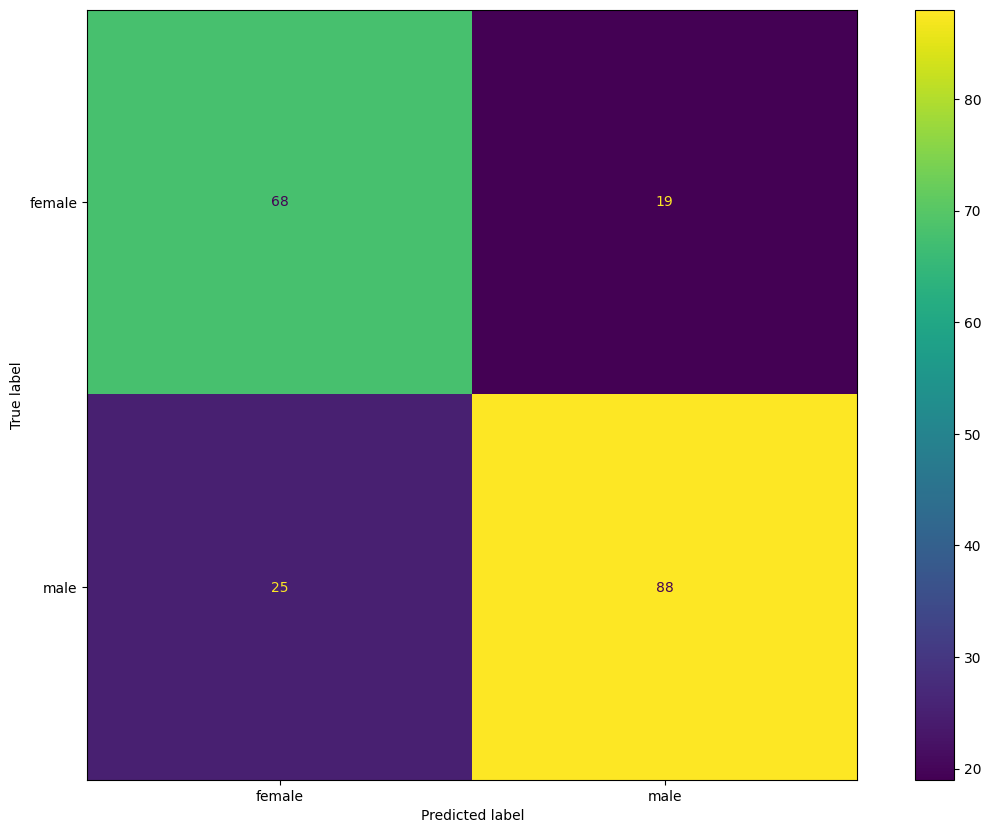

In [ ]:
print(classification_report(y_true, y_codebert_test_pred, target_names=enc.classes_.tolist()))

print("f1_score_macro : ",f1_score(y_true, y_codebert_test_pred, average='macro'))
print("f1_score_weighted : ",f1_score(y_true, y_codebert_test_pred, average='weighted'))

disp = ConfusionMatrixDisplay(confusion_matrix=confusion_matrix(y_true, y_codebert_test_pred), display_labels=enc.classes_.tolist())

fig, ax = plt.subplots(figsize=(15,10))
disp.plot(ax=ax)

plt.show()

In [ ]:
# Test the model and print out the confusion matrix
model.eval()
y_true = []
y_codebert_train_pred = []
with torch.no_grad():
    for batch in train_dataloader:
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['labels'].to(device)
        outputs = model(input_ids, attention_mask=attention_mask)
        logits = outputs.logits
        predictions = torch.argmax(logits, dim=1)
        y_true += labels.tolist()
        y_codebert_train_pred += predictions.tolist()

              precision    recall  f1-score   support

      female       0.81      0.85      0.83       304
        male       0.88      0.85      0.86       394

    accuracy                           0.85       698
   macro avg       0.84      0.85      0.84       698
weighted avg       0.85      0.85      0.85       698

f1_score_macro :  0.8448163731754195
f1_score_weighted :  0.8470237083653899


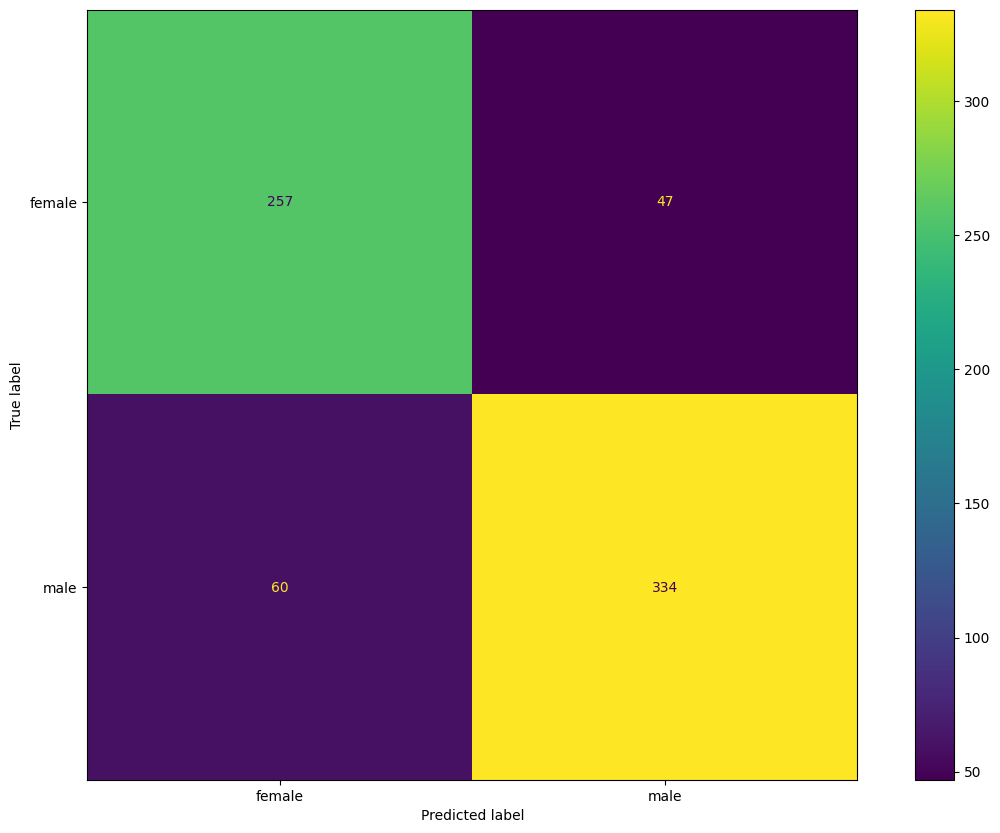

In [ ]:
print(classification_report(y_true, y_codebert_train_pred, target_names=enc.classes_.tolist()))

print("f1_score_macro : ",f1_score(y_true, y_codebert_train_pred, average='macro'))
print("f1_score_weighted : ",f1_score(y_true, y_codebert_train_pred, average='weighted'))

disp = ConfusionMatrixDisplay(confusion_matrix=confusion_matrix(y_true, y_codebert_train_pred), display_labels=enc.classes_.tolist())

fig, ax = plt.subplots(figsize=(15,10))
disp.plot(ax=ax)

plt.show()

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import f1_score
import gensim

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.2, random_state=0,stratify=Y)

In [ ]:
model_name = "neulab/codebert-python"
tokenizer = RobertaTokenizer.from_pretrained(model_name)
model = RobertaModel.from_pretrained(model_name)

code_snippets = X['parsed_code'].tolist()

# Step 1: Encode the code snippets using CodeBERT
def get_embeddings(code_snippet):
    inputs = tokenizer(code_snippet, return_tensors='pt', truncation=True, padding=True, max_length=512)
    with torch.no_grad():
        outputs = model(**inputs)
    # Use the last hidden state of the [CLS] token as the embedding
    return outputs.last_hidden_state[:, 0, :].numpy()

# Get embeddings for all code snippets
embeddings = np.vstack([get_embeddings(snippet) for snippet in code_snippets])

embeddings_train, embeddings_test, y_train, y_test = train_test_split(embeddings, Y, test_size=0.2, random_state=0,stratify=Y)

Some weights of RobertaModel were not initialized from the model checkpoint at neulab/codebert-python and are newly initialized: ['roberta.pooler.dense.bias', 'roberta.pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [ ]:
X_nontext=X.select_dtypes(exclude=['object'])
X_nontext.info()

<class 'pandas.core.frame.DataFrame'>
Index: 998 entries, 0 to 999
Data columns (total 18 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   number_of_lines              998 non-null    float64
 1   num_of_sections              998 non-null    int64  
 2   token_count                  998 non-null    int64  
 3   variables_count              998 non-null    int64  
 4   function_count               998 non-null    int64  
 5   loop_count                   998 non-null    int64  
 6   condition_count              998 non-null    int64  
 7   single_line_comment_density  998 non-null    float64
 8   function_density             998 non-null    float64
 9   loop_density                 998 non-null    float64
 10  condition_density            998 non-null    float64
 11  comment_tokens_density       998 non-null    float64
 12  avg_var_name_length          998 non-null    float64
 13  comment_to_code_ratio    

In [ ]:
baseline_model = Pipeline([('scaler',StandardScaler()),
                           ('classifier',SVC())])

In [ ]:
X_train_nontext = X_train.select_dtypes(exclude=['object'])
X_test_nontext = X_test.select_dtypes(exclude=['object'])

X_train_combined=pd.concat([pd.DataFrame(embeddings_train, columns=['codebert_'+str(i) for i in range(768)], index=X_train_nontext.index),X_train_nontext],axis=1)
X_test_combined=pd.concat([pd.DataFrame(embeddings_test, columns=['codebert_'+str(i) for i in range(768)], index=X_test_nontext.index),X_test_nontext],axis=1)

In [ ]:
scores = cross_val_score(baseline_model, X_train_nontext, y_train, cv=5)
print("baseline model score: ",np.mean(scores))

scores = cross_val_score(baseline_model, embeddings_train, y_train, cv=5)
print("baseline model score: ",np.mean(scores))

scores = cross_val_score(baseline_model, X_train_combined, y_train, cv=5)
print("baseline model score: ",np.mean(scores))

baseline model score:  0.6528930817610064
baseline model score:  0.6879874213836479
baseline model score:  0.6892295597484276


In [ ]:
param_grid = {
    'classifier__C': [0.1, 1, 10, 100],
    'classifier__gamma': ['scale', 'auto'],
    'classifier__kernel': ['linear', 'poly', 'rbf', 'sigmoid']
}

grid_search = GridSearchCV(estimator=baseline_model, param_grid=param_grid,
                           cv=5, n_jobs=-1, verbose=2, scoring='f1_macro')

grid_search.fit(X_train_combined, y_train)

print("Best parameters found: ", grid_search.best_params_)
print("Best F1 score found: ", grid_search.best_score_)

best_svc = grid_search.best_estimator_
y_pred = best_svc.predict(X_test_combined)
print("Test set F1 macro score: ", f1_score(y_test, y_pred, average='macro'))
print("Test set F1 weighted score: ", f1_score(y_test, y_pred, average='weighted'))

Fitting 5 folds for each of 32 candidates, totalling 160 fits
Best parameters found:  {'classifier__C': 1, 'classifier__gamma': 'scale', 'classifier__kernel': 'rbf'}
Best F1 score found:  0.6794811870667374
Test set F1 macro score:  0.721964782205746
Test set F1 weighted score:  0.7281093605189991
